In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan
import scipy.stats as sts
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.inspection import PartialDependenceDisplay
from statsmodels.stats.stattools import jarque_bera, durbin_watson
import patsy

df = pd.read_csv('../data/ceo_salary_1990.csv')
print(df.head())
print(df.info())
print(df.describe())

   salary  pcsalary    sales   roe  pcroe  ros  indus  finance  consprod  \
0    1095        20  27595.0  14.1  106.4  191      1        0         0   
1    1001        32   9958.0  10.9  -30.6   13      1        0         0   
2    1122         9   6125.9  23.5  -16.3   14      1        0         0   
3     578        -9  16246.0   5.9  -25.7  -21      1        0         0   
4    1368         7  21783.2  13.8   -3.0   56      1        0         0   

   utility   lsalary     lsales  
0        0  6.998509  10.225390  
1        0  6.908755   9.206132  
2        0  7.022868   8.720281  
3        0  6.359574   9.695602  
4        0  7.221105   9.988894  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   salary    209 non-null    int64  
 1   pcsalary  209 non-null    int64  
 2   sales     209 non-null    float64
 3   roe       209 non-null    float64



 Simple linear regression summary: 

                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     55.30
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           2.70e-12
Time:                        18:30:10   Log-Likelihood:                -152.50
No. Observations:                 209   AIC:                             309.0
Df Residuals:                     207   BIC:                             315.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

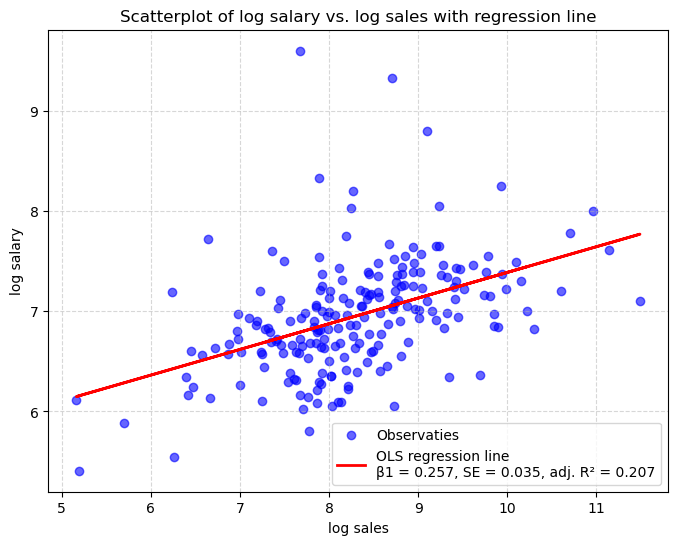

In [22]:
#simple linear regression lsalary vs. lsales
X_simple = df[['lsales']]
y_simple = df['lsalary']

X_simple = sm.add_constant(X_simple)
model_simple = sm.OLS(y_simple, X_simple).fit()

beta1 = model_simple.params['lsales']
se_beta1 = model_simple.bse['lsales']
adj_r2 = model_simple.rsquared_adj
reg_label = f'OLS regression line\nβ1 = {beta1:.3f}, SE = {se_beta1:.3f}, adj. R² = {adj_r2:.3f}'


print('\n Simple linear regression summary: \n')
print(model_simple.summary())

y_pred_simple = model_simple.predict(X_simple) 
plt.figure(figsize=(8, 6))
plt.scatter(df['lsales'], df['lsalary'], color='blue', alpha=0.6, label='Observaties')
plt.plot(df['lsales'], y_pred_simple, color='red', linewidth=2, label=reg_label)
plt.xlabel('log sales')
plt.ylabel('log salary')
plt.title('Scatterplot of log salary vs. log sales with regression line')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

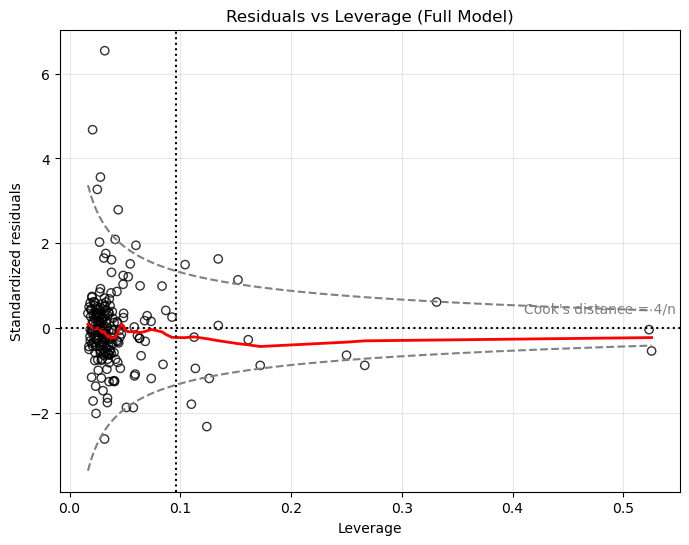

Number of influential observations removed: 16


In [23]:
#Searching for outliers
full_vars = ['lsales','sales','roe','ros','pcroe','pcsalary','finance','consprod','utility']

X_full = df[full_vars]
y = df['lsalary']
X_full_const = sm.add_constant(X_full)

full_model = sm.OLS(y, X_full_const).fit()
influence = full_model.get_influence()

leverage = influence.hat_matrix_diag
std_resid = influence.resid_studentized_external

lowess = sm.nonparametric.lowess
smoothed = lowess(std_resid, leverage, frac=0.3)

n = len(y)
p = X_full_const.shape[1]
cook_thresh = 4 / n

lev_range = np.linspace(min(leverage), max(leverage), 200)
cook_curve = np.sqrt(cook_thresh * p * (1 - lev_range) / lev_range)

plt.figure(figsize=(8,6))
plt.scatter(leverage, std_resid, facecolors='none',
            edgecolors='black', alpha=0.8)

plt.plot(smoothed[:,0], smoothed[:,1],
         color='red', linewidth=2)

plt.plot(lev_range, cook_curve, '--', color='gray')
plt.plot(lev_range, -cook_curve, '--', color='gray')

plt.text(lev_range[-1]*0.78, cook_curve[-1]*0.85,
         "Cook's distance = 4/n", color='gray')

plt.axhline(0, linestyle=':', color='black')
plt.axvline(2 * p / n, linestyle=':', color='black')

plt.xlabel("Leverage")
plt.ylabel("Standardized residuals")
plt.title("Residuals vs Leverage (Full Model)")
plt.grid(alpha=0.3)
plt.show()

cooks_d, _ = influence.cooks_distance
outlier_idx = np.where(cooks_d > cook_thresh)[0]

print(f"Number of influential observations removed: {len(outlier_idx)}")

We choose to include all the outliers as they form almost 1/10 of our data set and because our data set already contains only 209 datapoints, removing them would have a large effect on our regression. Therefore we only choose to incorparate the log transformation to deal with outliers, instead of removing those points. 

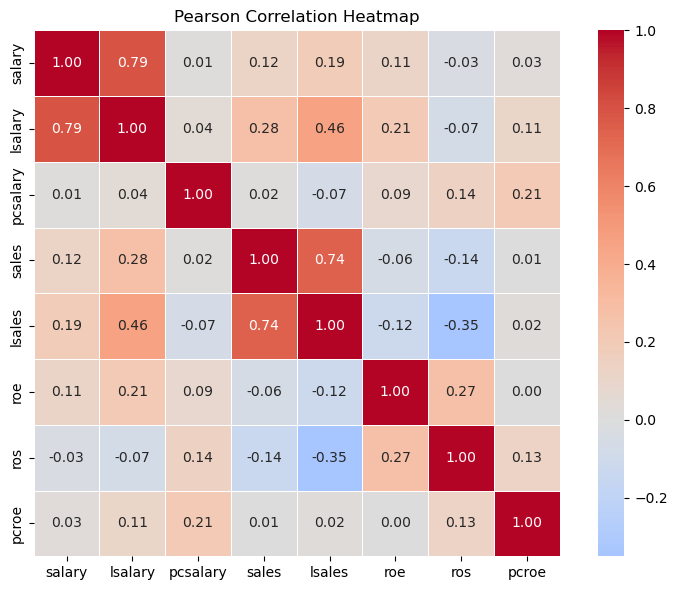

In [24]:
#Checking for correlation
def correlation_heatmap(df, vars_list, method='pearson', figsize=(8, 6)):
    data = df[vars_list]
    corr = data.corr(method=method)
    plt.figure(figsize=figsize)
    sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,square=True,linewidths=0.5)
    plt.title(f"{method.capitalize()} Correlation Heatmap")
    plt.tight_layout()
    plt.show()

x_vars = ['sales', 'lsales', 'roe', 'ros', 'pcroe']
y_vars = ['salary', 'lsalary', 'pcsalary']

all_vars = y_vars + x_vars
correlation_heatmap(df, all_vars)

In [25]:
#Expanding with extra variables
m2 = smf.ols(formula="lsalary ~ lsales + roe", data=df).fit()
print('lsalary ~ lsales + roe\n', m2.summary())

m3 = smf.ols(formula="lsalary ~ lsales + ros", data=df).fit()
print('lsalary ~ lsales + ros\n', m3.summary())

m4 = smf.ols(formula="lsalary ~ lsales + pcroe", data=df).fit()
print('lsalary ~ lsales + pcroe\n', m4.summary())

m5 = smf.ols(formula="lsalary ~ lsales + roe + ros", data=df).fit()
print('lsalary ~ lsales + roe + ros\n', m5.summary())

m6 = smf.ols(formula="lsalary ~ lsales + roe + pcroe", data=df).fit()
print('lsalary ~ lsales + roe + pcroe\n', m6.summary())

m7 = smf.ols(formula="lsalary ~ lsales + ros + pcroe", data=df).fit()
print('lsalary ~ lsales + ros + pcroe\n', m7.summary())

m8 = smf.ols(formula="lsalary ~ lsales + roe + pcroe + ros", data=df).fit()
print('\nlsalary ~ lsales + roe + pcroe + ros')
print(m8.summary())



lsalary ~ lsales + roe
                             OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     40.45
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           1.52e-15
Time:                        18:30:15   Log-Likelihood:                -142.62
No. Observations:                 209   AIC:                             291.2
Df Residuals:                     206   BIC:                             301.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.3622      0

The highest adjusted R2 is given by model 6: lsalary ~ lsales + roe + pcroe. But here pcroe is insignificant. Also for model 9: lsalary ~ lsales + roe + pcroe + ros, we have that pcroe and ros are insignificant. The adjusted R2 of 0.277 is only slightly larger then the more simpler model of: lsalary ~ lsales + roe. Also for this model all the variables are significant. So therefore the better model in this situation is the simpler model with adjusted R2 of 0.275. As ROS and PCROE are insignificant, adding them only add to the complexity of the model.

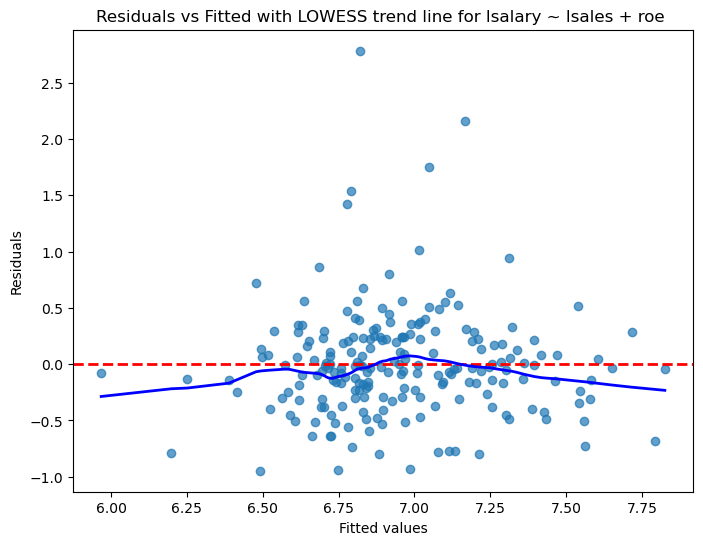

In [26]:
#Searching for functional misspecification
indep_vars2 = ['lsales', 'roe']
X_2 = df[indep_vars2]
y_2 = df['lsalary']

fitted_vals_2 = m2.predict(X_2)
residuals_2 = y_2 - fitted_vals_2

plt.figure(figsize=(8,6))
plt.scatter(fitted_vals_2, residuals_2, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)  

lowess = sm.nonparametric.lowess
smoothed = lowess(residuals_2, fitted_vals_2, frac=0.3)  
plt.plot(smoothed[:,0], smoothed[:,1], color='blue', linewidth=2)

plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted with LOWESS trend line for lsalary ~ lsales + roe ')
plt.show()


In the residuals vs Fitted values is a small U-shape visible. This can be caused by a small effect of deminishing marginal returns of the firm sizes. This makes sense as for small firms the increase in sales has a larger effect on the CEO salary in comparison to already large firms. To test our initial thought we used the RESET test. 

In [27]:
#RESET test
reset_test = linear_reset(m2, power=2, use_f=True)
f_stat = reset_test.fvalue
p_val = reset_test.pvalue
print(f"Model 2 - F-statistic: {f_stat:.3f}, p-value: {p_val:.3f}")

Model 2 - F-statistic: 5.101, p-value: 0.025


The null hypothesis of the RESET test is that the model is correctly specified. That is, the functional form is appropriate and there are no omitted nonlinear relationships among the predictors. The alternative hypothesis is that the model is misspecified. For example, there may be omitted nonlinear terms or interactions that the current linear model does not capture.

Because the p-value is below 0.05, at 5% significance level we reject the null hypothesis and therefore there is statistical evidence of functional misspecification. To incorparate for this nonlinear effect we will add a new term: l_sales_squared.


lsalary ~ lsales + lsales_sq + roe
                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     28.51
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           1.89e-15
Time:                        18:30:19   Log-Likelihood:                -140.80
No. Observations:                 209   AIC:                             289.6
Df Residuals:                     205   BIC:                             303.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1

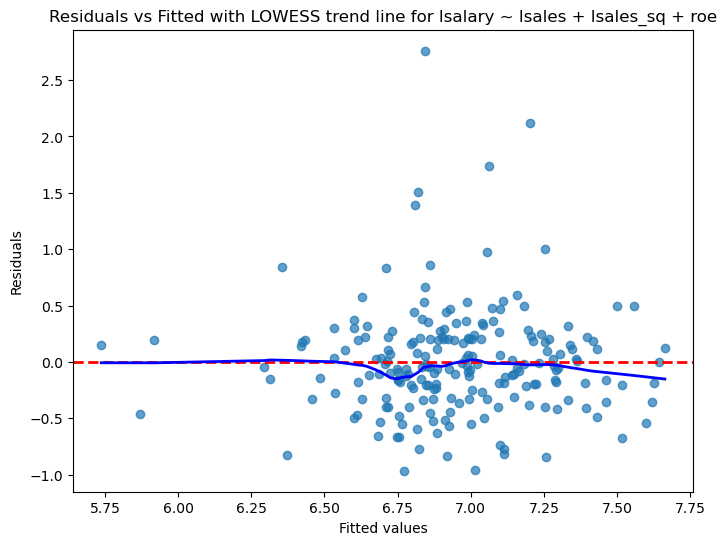

Model 9 - F-statistic: 0.890, p-value: 0.347


In [28]:
# Nonlinear term
df['lsales_sq'] = df['lsales'] ** 2

m9 = smf.ols(formula="lsalary ~ lsales + lsales_sq + roe", data=df).fit()
print('\nlsalary ~ lsales + lsales_sq + roe')
print(m9.summary())

indep_vars_9 = ['lsales', 'lsales_sq', 'roe']
X_9 = df[indep_vars_9]
y_9 = df['lsalary']

fitted_vals_9 = m9.predict(X_9)
residuals_9 = y_9 - fitted_vals_9

plt.figure(figsize=(8,6))
plt.scatter(fitted_vals_9, residuals_9, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)  

lowess = sm.nonparametric.lowess
smoothed = lowess(residuals_9, fitted_vals_9, frac=0.3)  
plt.plot(smoothed[:,0], smoothed[:,1], color='blue', linewidth=2)

plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted with LOWESS trend line for lsalary ~ lsales + lsales_sq + roe')
plt.show()

reset_test = linear_reset(m9, power=2, use_f=True)
f_stat = reset_test.fvalue
p_val = reset_test.pvalue
print(f"Model 9 - F-statistic: {f_stat:.3f}, p-value: {p_val:.3f}")

We see that after adding the squared term the U-shape disappears. Besides the RESET test tells us that there is no evidence for functional misspecification. Therefore we can assume that the form of misspecification came from the nonlinear relation between lsalary and lsales. Because the coefficient of lsales is positive and the coefficient of lsales_sq is negative, we have deminishing marginal returns. Only there is a new problem: multicollinearity.

In [29]:
#VIF and demeaning
X_vif = df[['lsales', 'lsales_sq', 'roe']]
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\nVIF with squared term:")
print(vif_data)

df['lsales_c'] = df['lsales'] - df['lsales'].mean()
df['lsales_c_sq'] = df['lsales_c']**2

m10 = smf.ols(formula="lsalary ~ lsales_c + lsales_c_sq + roe", data=df).fit()
print('\nlsalary ~ lsales_c + lsales_c_sq + roe')
print(m10.summary())

X_vif_c = df[['lsales_c', 'lsales_c_sq', 'roe']]
X_vif_c = sm.add_constant(X_vif_c)

vif_data_c = pd.DataFrame()
vif_data_c['Variable'] = X_vif_c.columns
vif_data_c['VIF'] = [variance_inflation_factor(X_vif_c.values, i) for i in range(X_vif_c.shape[1])]

print("\nVIF after centering the data:")
print(vif_data_c)



VIF with squared term:
    Variable          VIF
0      const  1741.274992
1     lsales   100.837913
2  lsales_sq   100.658182
3        roe     1.020025

lsalary ~ lsales_c + lsales_c_sq + roe
                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     28.51
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           1.89e-15
Time:                        18:30:21   Log-Likelihood:                -140.80
No. Observations:                 209   AIC:                             289.6
Df Residuals:                     205   BIC:                             303.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                

So the VIF test shows that the multicollinearity comes from lsales and lsales_sq. We see that after we demeaning both terms the multicollinearity disapears. 

In [30]:
# Expand the model by adding types of companies
performance_1 = ['lsales_c', 'lsales_c_sq', 'roe', 'pcroe', 'ros']
performance_2 = ['lsales_c', 'lsales_c_sq', 'roe']
performance_3 = ['lsales_c', 'lsales_c_sq', 'roe', 'ros']
dummies = ['finance', 'consprod', 'utility']

x_vars = sm.add_constant(df[performance_1 + dummies])
m_d = sm.OLS(df['lsalary'], x_vars).fit()
print('lsalary ~ lsales_c + lsales_c_sq + roe + pcroe + ros + finance + consprod + utility\n', m_d.summary())

x_vars_2 = sm.add_constant(df[performance_2 + dummies])
m_d_2 = sm.OLS(df['lsalary'], x_vars_2).fit()
print('lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility\n', m_d_2.summary())

x_vars_3 = sm.add_constant(df[performance_3 + dummies])
m_d_3 = sm.OLS(df['lsalary'], x_vars_3).fit()
print('lsalary ~ lsales_c + lsales_c_sq + roe + ros + finance + consprod + utility\n', m_d_3.summary())

m11 = smf.ols(formula='lsalary ~ lsales_c + lsales_c_sq + finance + consprod + utility', data=df).fit()
print('\nlsalary ~ lsales_c + lsales_c_sq + finance + consprod + utility')
print(m11.summary())


lsalary ~ lsales_c + lsales_c_sq + roe + pcroe + ros + finance + consprod + utility
                             OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.368
Method:                 Least Squares   F-statistic:                     16.12
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           2.74e-18
Time:                        18:30:22   Log-Likelihood:                -125.24
No. Observations:                 209   AIC:                             268.5
Df Residuals:                     200   BIC:                             298.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

To avoid the dummy trap, we excluded one of the variables. Therefore we also have to add the dummy variables that are not statistically significant. Now also the squared term is statistically significant. 

In [31]:
#Negative ROS vs. Positive ROS
df['NegROS'] = (df['ros'] < 0).astype(int)

m11 = smf.ols(formula="lsalary ~ lsales_c + lsales_c_sq + roe + NegROS + finance + consprod + utility", data=df).fit()
print('\nlsalary ~ lsales_c + lsales_c_sq + roe + NegROS + finance + consprod + utility')
print(m11.summary())

m12 = smf.ols(formula="lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility", data=df).fit()
print('\nlsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility')
print(m12.summary())


lsalary ~ lsales_c + lsales_c_sq + roe + NegROS + finance + consprod + utility
                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     19.44
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           9.30e-20
Time:                        18:30:23   Log-Likelihood:                -123.21
No. Observations:                 209   AIC:                             262.4
Df Residuals:                     201   BIC:                             289.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

NegROS is significant and indicates that there is a negative correlation between NegROS and the log of CEO salary. Indicating that when the return on stock is negative, the CEO salary in general is lower. Also the adjusted R2 is somewhat higher. Therefore, we will inlcude this model in our cross validation.

We can see that a model combining NegROS and ROE has a slightly better adjusted R2, but as we can see ROE becomes statistically insignificant, indicating that, the both measures tell the same story and therefore it is better to only choose one of the firm performance measures, as it makes the model simpler and better to interperate. 

In [68]:
#Cross Validation

def kfold_cv(df, formula, k=5, random_state=42):
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    mse_scores = []

    for train_idx, val_idx in kf.split(df):
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        model = smf.ols(formula=formula, data=train_df).fit()
        y_val_pred = model.predict(val_df)

        y_val = val_df[formula.split("~")[0].strip()]
        mse_scores.append(mean_squared_error(y_val, y_val_pred))

    return np.mean(mse_scores), np.std(mse_scores)

def loocv(df, formula): 
    loo = LeaveOneOut()
    mse_scores = []
    y_var = formula.split("~")[0].strip()

    for train_idx, val_idx in loo.split(df):
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        model = smf.ols(formula=formula, data=train_df).fit()
        y_val_pred = model.predict(val_df)

        y_val = val_df[y_var]
        mse_scores.append(mean_squared_error(y_val, y_val_pred))

    return np.mean(mse_scores), np.std(mse_scores)

def select_model_cv(df, models, cv_method, k=5, test_size=0.2, random_state=42):
    train_df, test_df = train_test_split(df, test_size=test_size, random_state=random_state)
    print(f"Train size: {len(train_df)}, Test size: {len(test_df)}\n")
    
    cv_results = {}
    test_results = {}
    
    print(f"Cross-validation results with {cv_method} and test size of {test_size}")
    print("-" * 80)

    # ---------- CV for each model ----------
    for name, formula in models.items():
        if cv_method == "kfold":
            mean_mse, std_mse = kfold_cv(train_df, formula, k=k, random_state=random_state)
        elif cv_method == "loocv":
            mean_mse, std_mse = loocv(train_df, formula)
        else:
            raise ValueError("cv_method must be 'kfold' or 'loocv'")

        cv_results[name] = (mean_mse, std_mse)

        # ---------- Fit on full training set & evaluate on test set ----------
        final_model = smf.ols(formula=formula, data=train_df).fit()
        y_test = test_df[formula.split("~")[0].strip()]
        y_test_pred = final_model.predict(test_df)

        test_mse = mean_squared_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        test_rmse = np.sqrt(test_mse)

        test_results[name] = {
            "test_mse": test_mse,
            "test_rmse": test_rmse,
            "test_r2": test_r2
        }

        print(
            f"{name}: CV MSE = {mean_mse:.4f} (± {std_mse:.4f}), "
            f"Test MSE = {test_mse:.4f}, "
            f"Test RMSE = {test_rmse:.4f}, "
            f"Test R² = {test_r2:.4f}"
        )

    # ---------- Select best model by CV ----------
    best_model_name = min(cv_results, key=lambda x: cv_results[x][0])
    best_formula = models[best_model_name]

    print("\nSelected model (by CV MSE)")
    print("-" * 80)
    print(best_model_name)
    print(best_formula)
    print(
        f"CV MSE = {cv_results[best_model_name][0]:.4f} "
        f"(± {cv_results[best_model_name][1]:.4f}), "
        f"Test MSE = {test_results[best_model_name]['test_mse']:.4f}, "
        f"Test R² = {test_results[best_model_name]['test_r2']:.4f}"
    )


models = {
    'Model 1': 'lsalary ~ lsales_c + lsales_c_sq + finance + consprod + utility',
    'Model 2': 'lsalary ~ lsales_c + lsales_c_sq + roe + ros + pcroe + finance + consprod + utility',
    'Model 3': 'lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility',
    'Model 4': 'lsalary ~ lsales_c + lsales_c_sq + roe + ros + finance + consprod + utility',
    'Model 5': 'lsalary ~ lsales_c + lsales_c_sq + roe + NegROS + finance + consprod + utility',
    'Model 6': 'lsalary ~ lsales_c + lsales_c_sq + roe + pcroe + NegROS + finance + consprod + utility',
    'Model 7': 'lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility',
    'Model 8': 'lsalary ~ roe + pcroe + NegROS + finance + consprod + utility'}




df['lsales_c'] = df['lsales'] - df['lsales'].mean()
df['lsales_c_sq'] = df['lsales_c'] ** 2
df['NegROS'] = (df['ros'] < 0).astype(int)

select_model_cv(df, models, cv_method = 'kfold', k=5, test_size=0.2, random_state=123245)
select_model_cv(df, models, cv_method = 'loocv', k=5, test_size=0.2, random_state=123245)

Train size: 167, Test size: 42

Cross-validation results with kfold and test size of 0.2
--------------------------------------------------------------------------------
Model 1: CV MSE = 0.1975 (± 0.0457), Test MSE = 0.3145, Test RMSE = 0.5608, Test R² = 0.2918
Model 2: CV MSE = 0.1994 (± 0.0592), Test MSE = 0.3121, Test RMSE = 0.5587, Test R² = 0.2971
Model 3: CV MSE = 0.2002 (± 0.0592), Test MSE = 0.3123, Test RMSE = 0.5588, Test R² = 0.2968
Model 4: CV MSE = 0.1995 (± 0.0632), Test MSE = 0.3148, Test RMSE = 0.5610, Test R² = 0.2912
Model 5: CV MSE = 0.1929 (± 0.0629), Test MSE = 0.3039, Test RMSE = 0.5512, Test R² = 0.3157
Model 6: CV MSE = 0.1936 (± 0.0593), Test MSE = 0.3025, Test RMSE = 0.5500, Test R² = 0.3188
Model 7: CV MSE = 0.1872 (± 0.0521), Test MSE = 0.3068, Test RMSE = 0.5539, Test R² = 0.3092
Model 8: CV MSE = 0.2561 (± 0.0741), Test MSE = 0.4039, Test RMSE = 0.6355, Test R² = 0.0905

Selected model (by CV MSE)
----------------------------------------------------------

We still choose model 4, even if LOOCV slightly favors model 5. But with the extra insignificant term the model is more complex and therefore it has a higher variance. Although leave-one-out cross-validation marginally favors the more complex specification including PCROE, the improvement in predictive performance is negligible. Given the substantially higher variance of LOOCV and the near-identical out-of-sample test errors, the more simpler model is preferred. Consistent with k-fold cross-validation and the principle of simplicity, the simpler specification is selected as the final model.


=== Diagnostics for Model 1 (NegROS) ===

OLS Summary
                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     21.72
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           1.20e-19
Time:                        18:31:47   Log-Likelihood:                -125.21
No. Observations:                 209   AIC:                             264.4
Df Residuals:                     202   BIC:                             287.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

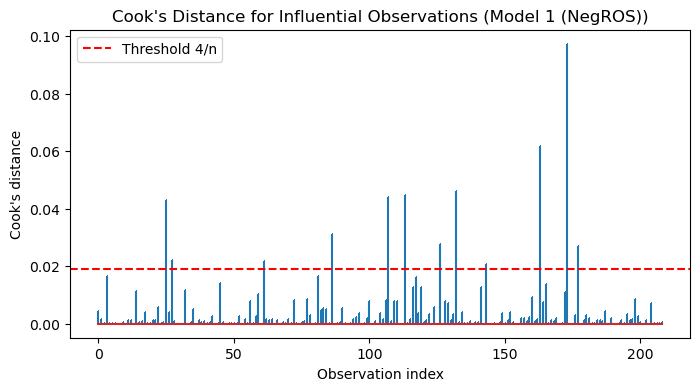


Number of potentially influential points (Cook's D > 4/n): 12
Indices: [ 25  27  61  86 107 113 126 132 143 163 173 177]

=== Diagnostics for Model 2 (ROE) ===

OLS Summary
                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     20.82
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           6.07e-19
Time:                        18:31:47   Log-Likelihood:                -126.94
No. Observations:                 209   AIC:                             267.9
Df Residuals:                     202   BIC:                             291.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err   

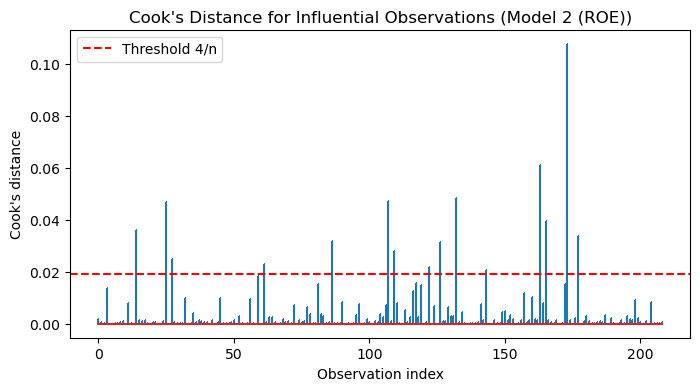


Number of potentially influential points (Cook's D > 4/n): 15
Indices: [ 14  25  27  61  86 107 109 122 126 132 143 163 165 173 177]


In [33]:
#Assumptions on the final model
df['lsales_c'] = df['lsales'] - df['lsales'].mean()
df['lsales_c_sq'] = df['lsales_c'] ** 2
df['NegROS'] = (df['ros'] < 0).astype(int)

# Define models
models = {
    "Model 1 (NegROS)": "lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility",
    "Model 2 (ROE)": "lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility"
}

def run_diagnostics(model_name, formula, data):
    print(f"\n=== Diagnostics for {model_name} ===\n")
    
    # Fit model
    model = smf.ols(formula=formula, data=data).fit()
    print("OLS Summary")
    print(model.summary())

    # 1. Functional form: RESET test
    reset_test = linear_reset(model, power=2, use_f=True)
    print("\nRESET Test (Functional Form)")
    print(f"F-statistic: {reset_test.fvalue:.3f}, p-value: {reset_test.pvalue:.3f}")

    # 2. Heteroskedasticity: Breusch-Pagan test
    bp_test = het_breuschpagan(model.resid, model.model.exog)
    labels = ['LM stat', 'LM p-value', 'F stat', 'F p-value']
    bp_results = dict(zip(labels, bp_test))
    print("\nBreusch-Pagan Test (Heteroskedasticity)")
    for k, v in bp_results.items():
        print(f"{k}: {v:.4f}")

    # 3. Normality of residuals: Jarque-Bera test
    jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model.resid)
    print("\nJarque-Bera Test (Normality)")
    print(f"JB-statistic: {jb_stat:.3f}, p-value: {jb_pvalue:.3f}, Skew: {skew:.3f}, Kurtosis: {kurtosis:.3f}")

    # 4. Independence of residuals: Durbin-Watson test
    dw_stat = durbin_watson(model.resid)
    print("\nDurbin-Watson Test (Autocorrelation)")
    print(f"DW-statistic: {dw_stat:.3f} (≈2 indicates no autocorrelation)")

    # 5. Multicollinearity: VIF
    X = model.model.exog
    vif_df = pd.DataFrame({
        "variable": model.model.exog_names,
        "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    })
    print("\nVariance Inflation Factors (VIF)")
    print(vif_df)

    # 6. Influential observations: Cook's distance
    influence = model.get_influence()
    cooks = influence.cooks_distance[0]

    plt.figure(figsize=(8,4))
    plt.stem(cooks, markerfmt=",")
    plt.axhline(4/len(data), color='r', linestyle='--', label='Threshold 4/n')
    plt.xlabel('Observation index')
    plt.ylabel("Cook's distance")
    plt.title(f"Cook's Distance for Influential Observations ({model_name})")
    plt.legend()
    plt.show()

    influential_points = np.where(cooks > 4/len(data))[0]
    print(f"\nNumber of potentially influential points (Cook's D > 4/n): {len(influential_points)}")
    print(f"Indices: {influential_points}")

    return model

# Run diagnostics for both models
best_model = run_diagnostics("Model 1 (NegROS)", models["Model 1 (NegROS)"], df)
best_model_2 = run_diagnostics("Model 2 (ROE)", models["Model 2 (ROE)"], df)

Our findings from these tests:
- No evidence for functional misspecification.
- No evidence for heteroskedasticity, so we can assume homoskedasticity.
- We have non-normal errors.
- Residuals are uncorrelated, so residuals are independent
- No multicollinearity

In [34]:
#Bootstrap against non-normal errors
formula = "lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility"
n_boot = 1000 
coefs_boot = []

for i in range(n_boot):
    sample_df = df.sample(n=len(df), replace=True)
    model_boot = smf.ols(formula=formula, data=sample_df).fit()
    coefs_boot.append(model_boot.params.values)

coefs_boot = np.array(coefs_boot)
boot_se = coefs_boot.std(axis=0)

ci_lower = np.percentile(coefs_boot, 2.5, axis=0)
ci_upper = np.percentile(coefs_boot, 97.5, axis=0)

p_values_boot = []
for j in range(coefs_boot.shape[1]):
    prob_less_zero = np.mean(coefs_boot[:, j] <= 0)
    prob_greater_zero = np.mean(coefs_boot[:, j] >= 0)
    p_val = 2 * min(prob_less_zero, prob_greater_zero)
    p_values_boot.append(p_val)

coef_names = best_model.params.index
bootstrap_results = pd.DataFrame({
    'Coefficient': coef_names,
    'Original Estimate': best_model.params.values,
    'Bootstrap p-value': p_values_boot,
    'Bootstrap SE': boot_se,
    '95% CI Lower': ci_lower,
    '95% CI Upper': ci_upper})

print(bootstrap_results)

   Coefficient  Original Estimate  Bootstrap p-value  Bootstrap SE  \
0    Intercept           7.040620              0.000      0.046609   
1     lsales_c           0.267367              0.000      0.028673   
2  lsales_c_sq          -0.057197              0.006      0.018724   
3       NegROS          -0.314578              0.000      0.085860   
4      finance           0.071883              0.316      0.075762   
5     consprod           0.223125              0.004      0.087307   
6      utility          -0.447374              0.000      0.075026   

   95% CI Lower  95% CI Upper  
0      6.947043      7.125948  
1      0.209090      0.319507  
2     -0.094726     -0.022533  
3     -0.476881     -0.139999  
4     -0.073066      0.228108  
5      0.068779      0.406563  
6     -0.585470     -0.294339  


Given the presence of non-normal and heteroskedastic errors, inference based on classical OLS standard errors may be unreliable. Therefore, we rely on bootstrap-based standard errors, confidence intervals, and p-values. Statistical significance is assessed using percentile bootstrap p-values.

Test Accuracy (k=5): 0.76


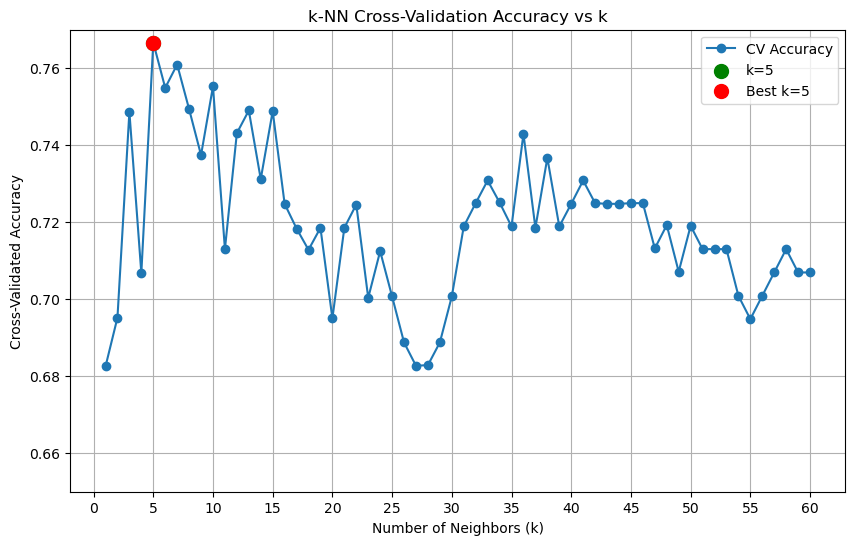

Best k found during tuning: 5
Best CV Accuracy: 0.77
Final Test Accuracy (Unseen Data): 0.76


In [36]:
#KNN in classification


X = df[['lsales_c', 'lsales_c_sq', 'NegROS', 'finance', 'consprod', 'utility']]
y_clf = (df['lsalary'] > df['lsalary'].median()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)


param_grid = {'knn__n_neighbors': range(1, 61)}
grid_search = GridSearchCV(Pipeline([('scaler', StandardScaler()),('knn', KNeighborsClassifier())]), 
                           param_grid, 
                           cv=5, 
                           scoring='accuracy')
grid_search.fit(X_train, y_train)

k_values = range(1, 61)
cv_scores = grid_search.cv_results_['mean_test_score']


knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train, y_train)
y_pred_5 = knn_5.predict(X_test)
accuracy_5 = accuracy_score(y_test, y_pred_5)
print(f"Test Accuracy (k=5): {accuracy_5:.2f}")


best_k = grid_search.best_params_['knn__n_neighbors']
best_score = grid_search.best_score_

plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', label='CV Accuracy')

# Highlight k=5
plt.scatter(5, cv_scores[4], color='green', s=100, zorder=5, label='k=5')

# Highlight best k
plt.scatter(best_k, best_score, color='red', s=100, zorder=5, label=f'Best k={best_k}')

plt.title("k-NN Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated Accuracy")
plt.xticks(range(0, 61, 5))
plt.ylim(0.65, 0.77)
plt.grid(True)
plt.legend()
plt.show()


y_pred_best = grid_search.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Best k found during tuning: {best_k}")
print(f"Best CV Accuracy: {best_score:.2f}")
print(f"Final Test Accuracy (Unseen Data): {final_accuracy:.2f}")


Test Accuracy (k=5): 0.67


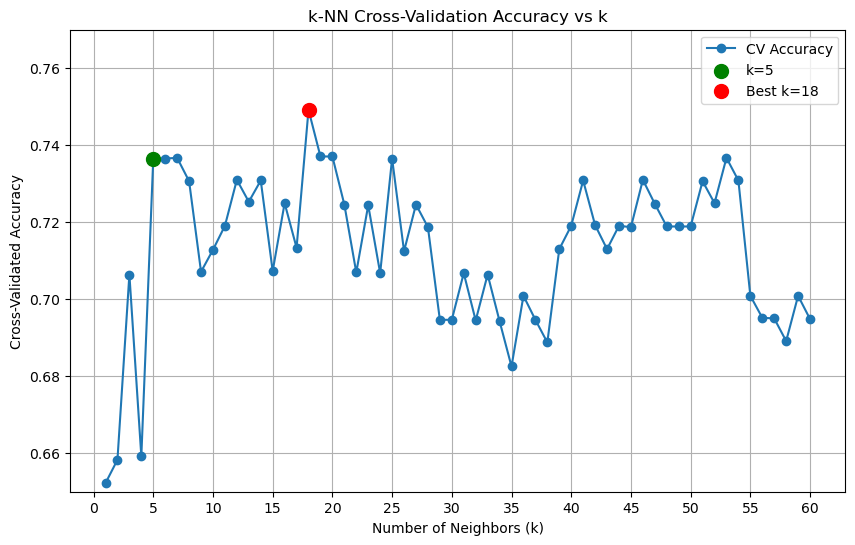

Best k found during tuning: 18
Best CV Accuracy: 0.75
Final Test Accuracy (Unseen Data): 0.74


In [38]:
#KNN in classification

X = df[['lsales_c', 'lsales_c_sq', 'finance', 'consprod', 'utility']]
y_clf = (df['lsalary'] > df['lsalary'].median()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)


param_grid = {'knn__n_neighbors': range(1, 61)}
grid_search = GridSearchCV(Pipeline([('scaler', StandardScaler()),('knn', KNeighborsClassifier())]), 
                           param_grid, 
                           cv=5, 
                           scoring='accuracy')
grid_search.fit(X_train, y_train)

k_values = range(1, 61)
cv_scores = grid_search.cv_results_['mean_test_score']


knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train, y_train)
y_pred_5 = knn_5.predict(X_test)
accuracy_5 = accuracy_score(y_test, y_pred_5)
print(f"Test Accuracy (k=5): {accuracy_5:.2f}")


best_k = grid_search.best_params_['knn__n_neighbors']
best_score = grid_search.best_score_

plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', label='CV Accuracy')

# Highlight k=5
plt.scatter(5, cv_scores[4], color='green', s=100, zorder=5, label='k=5')

# Highlight best k
plt.scatter(best_k, best_score, color='red', s=100, zorder=5, label=f'Best k={best_k}')

plt.title("k-NN Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated Accuracy")
plt.xticks(range(0, 61, 5))
plt.ylim(0.65, 0.77)
plt.grid(True)
plt.legend()
plt.show()


y_pred_best = grid_search.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Best k found during tuning: {best_k}")
print(f"Best CV Accuracy: {best_score:.2f}")
print(f"Final Test Accuracy (Unseen Data): {final_accuracy:.2f}")

In [39]:
#KNN in regression

models = {'Model 0': 'lsalary ~ lsales_c + lsales_c_sq + finance + consprod + utility',
    'Model 1': 'lsalary ~ lsales_c + lsales_c_sq + roe + ros + pcroe + finance + consprod + utility',
    'Model 2': 'lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility',
    'Model 3': 'lsalary ~ lsales_c + lsales_c_sq + roe + ros + finance + consprod + utility',
    'Model 4': 'lsalary ~ lsales_c + lsales_c_sq + roe + NegROS + finance + consprod + utility',
    'Model 5': 'lsalary ~ lsales_c + lsales_c_sq + roe + pcroe + NegROS + finance + consprod + utility',
    'Model 6': 'lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility',
    'Model 7': 'lsalary ~ roe + pcroe + NegROS + finance + consprod + utility'}


def nested_kfold_knn(df, formula, k_outer=5, k_inner=5, k_grid=range(3, 31), random_state_outer=42, random_state_inner=1):
    y, X = patsy.dmatrices(formula, data=df, return_type="dataframe")
    y = y.values.ravel()

    outer_cv = KFold(n_splits=k_outer, shuffle=True, random_state=random_state_outer)
    inner_cv = KFold(n_splits=k_inner, shuffle=True, random_state=random_state_inner)

    outer_mse = []
    best_ks = []

    for train_idx, val_idx in outer_cv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Inner crossvalidation to choose best k
        mean_mse_per_k = []

        for k in k_grid:
            inner_mse = []

            for inner_train_idx, inner_val_idx in inner_cv.split(X_train):
                X_inner_train = X_train.iloc[inner_train_idx]
                X_inner_val = X_train.iloc[inner_val_idx]
                y_inner_train = y_train[inner_train_idx]
                y_inner_val = y_train[inner_val_idx]

                pipeline = Pipeline([
                    ("scaler", StandardScaler()),
                    ("knn", KNeighborsRegressor(n_neighbors=k))
                ])

                pipeline.fit(X_inner_train, y_inner_train)
                y_inner_pred = pipeline.predict(X_inner_val)
                inner_mse.append(mean_squared_error(y_inner_val, y_inner_pred))

            mean_mse_per_k.append(np.mean(inner_mse))

        best_k = k_grid[np.argmin(mean_mse_per_k)]
        best_ks.append(best_k)

        # Outer cross validation to compute cv mse
        final_pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsRegressor(n_neighbors=best_k))])

        final_pipeline.fit(X_train, y_train)
        y_val_pred = final_pipeline.predict(X_val)
        outer_mse.append(mean_squared_error(y_val, y_val_pred))

    return {
        "cv_mse_mean": np.mean(outer_mse),
        "cv_mse_std": np.std(outer_mse),
        "best_k_median": int(np.median(best_ks)),
        "best_ks": best_ks}

def select_knn_model_cv(df, models, k_outer=5, k_inner=5, k_grid=range(3, 60), test_size=0.2, random_state=42):
    train_df, test_df = train_test_split(df, test_size=test_size, random_state=random_state)

    print(f"Train size: {len(train_df)}, Test size: {len(test_df)}\n")
    print("Nested K-Fold CV results (KNN)")
    print("-" * 80)

    results = {}

    for name, formula in models.items():
        res = nested_kfold_knn(train_df, formula, k_outer=k_outer, k_inner=k_inner, k_grid=k_grid)

        best_k = res["best_k_median"]

        y_train, X_train = patsy.dmatrices(formula, train_df, return_type="dataframe")
        y_train = y_train.values.ravel()

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsRegressor(n_neighbors=best_k))])

        pipeline.fit(X_train, y_train)

        y_test, X_test = patsy.dmatrices(formula, test_df, return_type="dataframe")
        y_test = y_test.values.ravel()

        y_test_pred = pipeline.predict(X_test)

        test_mse = mean_squared_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)

        results[name] = {
            **res,
            "best_k": best_k,
            "test_mse": test_mse,
            "test_r2": test_r2}

        print(
            f"{name}: "
            f"CV MSE = {res['cv_mse_mean']:.4f} (± {res['cv_mse_std']:.4f}), "
            f"k = {best_k}, "
            f"Test MSE = {test_mse:.4f}, "
            f"Test R² = {test_r2:.4f}")

    best_model_name = min(results, key=lambda x: results[x]["cv_mse_mean"])
    best_model = results[best_model_name]

    print("\nSelected model (by CV MSE)")
    print("-" * 80)
    print(best_model_name)
    print(models[best_model_name])
    print(f"Selected k: {best_model['best_k']}")
    print(f"Test MSE: {best_model['test_mse']:.4f}")
    print(f"Test R²: {best_model['test_r2']:.4f}")


select_knn_model_cv(df,models,k_outer=5,k_inner=5,k_grid=range(3, 60),test_size=0.2,random_state=1234)


Train size: 167, Test size: 42

Nested K-Fold CV results (KNN)
--------------------------------------------------------------------------------
Model 0: CV MSE = 0.2458 (± 0.1194), k = 7, Test MSE = 0.2776, Test R² = 0.1854
Model 1: CV MSE = 0.2526 (± 0.1128), k = 11, Test MSE = 0.2552, Test R² = 0.2511
Model 2: CV MSE = 0.2402 (± 0.1126), k = 9, Test MSE = 0.2645, Test R² = 0.2238
Model 3: CV MSE = 0.2405 (± 0.1082), k = 9, Test MSE = 0.2703, Test R² = 0.2067
Model 4: CV MSE = 0.2170 (± 0.1060), k = 9, Test MSE = 0.2595, Test R² = 0.2384
Model 5: CV MSE = 0.2231 (± 0.1023), k = 8, Test MSE = 0.2410, Test R² = 0.2928
Model 6: CV MSE = 0.2377 (± 0.1100), k = 6, Test MSE = 0.2776, Test R² = 0.1854
Model 7: CV MSE = 0.2819 (± 0.1396), k = 16, Test MSE = 0.2964, Test R² = 0.1304

Selected model (by CV MSE)
--------------------------------------------------------------------------------
Model 4
lsalary ~ lsales_c + lsales_c_sq + roe + NegROS + finance + consprod + utility
Selected k: 9
Test

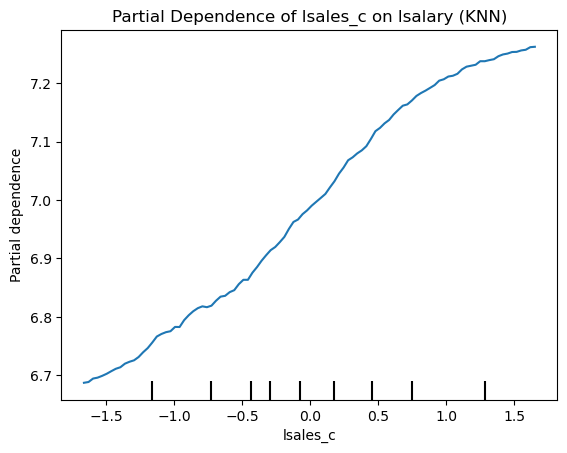

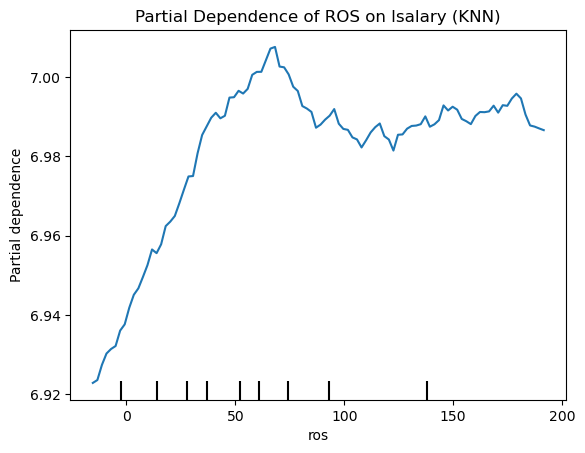

In [40]:
# Proof on non linear effect with partial dependence plot

# PDP on lsales_c
X = df[['lsales_c','roe', 'ros', 'finance', 'consprod', 'utility']]
y = df['lsalary']
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=9))])
knn_pipeline.fit(X, y)
PartialDependenceDisplay.from_estimator(knn_pipeline, X, features=['lsales_c'], kind='average')
plt.title("Partial Dependence of lsales_c on lsalary (KNN)")
plt.show()


# PDP on ROS
X = df[['lsales_c', 'roe','ros', 'finance', 'consprod', 'utility']]
y = df['lsalary']
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=9))])
knn_pipeline.fit(X, y)
PartialDependenceDisplay.from_estimator(knn_pipeline, X, features=['ros'], kind='average')
plt.title("Partial Dependence of ROS on lsalary (KNN)")
plt.show()
